# Modelamiento Preeliminar - UrbanSafe AI

**Proposito de este notebook**: construir un **modelo de pronostico honesto** para el TransMilenio
(conteo de validaciones, aforo y ETA por estacion/hora) en lugar de un modelo que *parece* predecir
pero en realidad memoriza la formula o evalua con datos ya vistos.

**Disciplina de series de tiempo** (segun el articulo *"Why So Many Time Series Models Fail in
Practice"* de James M., 2026). Los 5 fracasos que este notebook evita a proposito:

1. **Escalar todo el dataset antes de partir** -> fuga de informacion (leakage - Informacion del futuro en el entrenamiento).
2. **Barajar (shuffle) antes de dividir** -> aqui no se baraja: split **cronologico**.
3. **Asumir estacionariedad** -> se respeta el orden temporal y se valora con metricas por franja.
4. **Sobreajustar lags** -> se usan los minimos lags necesarios y se distingue **nowcasting** (solo datos ya observados) de **pronostico** (datos futuros).
5. **Confundir prediccion con pronostico** -> la seccion de Chronos pronostica a futuro en **walk-forward**, nunca con lags del mismo dia.

**Herramienta de pronostico**: [amazon-science/chronos-forecasting](https://github.com/amazon-science/chronos-forecasting),
modelo de lenguaje pre-entrenado sobre series de tiempo (`amazon/chronos-bolt-small`).

**Convencion de este notebook**: cada bloque trae una celda *markdown* que explica **que se va a
hacer**, el codigo, y una celda *markdown* posterior que explica **que muestra la salida**.


In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

def find_repo_root():
    p = Path(".").resolve()
    for up in [p] + list(p.parents):
        if (up / "deliveries").is_dir():
            return up
    raise FileNotFoundError("No se encontro la carpeta 'deliveries'. Corre el notebook desde el repo.")

ROOT = find_repo_root()
CSV_PATH = ROOT / "deliveries" / "week07" / "data_processed" / "dataset_limpio.csv"
OUT_DIR = ROOT / "deliveries" / "week07" / "data_processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("ROOT      :", ROOT)
print("CSV_PATH  :", CSV_PATH, "->", CSV_PATH.exists())


ROOT      : /home/evssz/UTEC/6to/DPD/DPD_project
CSV_PATH  : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/dataset_limpio.csv -> True


La salida muestra la raiz del repositorio detectada automaticamente y confirma que el dataset limpio existe. Este patron de rutas robustas (subir hasta encontrar `deliveries`) permite correr el notebook tanto en Colab como en local sin cambiar rutas a mano. El resto de secciones leeran este `CSV_PATH`.

In [2]:
df = pd.read_csv(CSV_PATH)

# Fecha y Hora vienen separadas (Hora = "HH"); se unifican en Fecha_Hora
df["Hora_n"] = df["Hora"].astype(str).str.zfill(2).str[:2].astype(int)
df["Fecha_Hora"] = pd.to_datetime(df["Fecha"]) + pd.to_timedelta(df["Hora_n"], unit="h")

print("Filas x columnas:", df.shape)
print("Estaciones      :", df["Estacion"].nunique())
print("Rango fechas    :", df["Fecha_Hora"].min(), "->", df["Fecha_Hora"].max())
df.head()


Filas x columnas: (176783, 30)
Estaciones      : 156
Rango fechas    : 2026-07-01 03:00:00 -> 2026-08-31 23:00:00


,num_est,Fecha,Hora,Linea,Tipo_Dia,Estacion,Latitud,Longitud,Ubicacion,Troncal,Fase,Cap_ART,Cap_BIART,Frecuencia,Headway_Min,N_Rutas,Validaciones,Es_Festivo,Tipo_Dia_ok,Sin_Oferta,Cap_total,sin_capacidad,DiaSemana,Franja,Es_Habil,Pax_bus,Ocupacion_pk,log_val,Hora_n,Fecha_Hora
0,2000,2026-07-01,4,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,93.0,0.65,16.0,507,False,Dia 1,False,210.0,False,Miércoles,madrugada,True,5.451613,2.414286,6.230481,4,2026-07-01 04:00:00
1,2000,2026-07-01,5,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,314.0,0.19,28.0,3976,False,Dia 1,False,210.0,False,Miércoles,pico am,True,12.662420,18.933333,8.288283,5,2026-07-01 05:00:00
2,2000,2026-07-01,6,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,391.0,0.15,31.0,8280,False,Dia 1,False,210.0,False,Miércoles,pico am,True,21.176471,39.428571,9.021719,6,2026-07-01 06:00:00
3,2000,2026-07-01,7,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,439.0,0.14,31.0,8980,False,Dia 1,False,210.0,False,Miércoles,pico am,True,20.455581,42.761905,9.102867,7,2026-07-01 07:00:00
4,2000,2026-07-01,8,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,FASE I,132.0,78.0,446.0,0.13,30.0,5727,False,Dia 1,False,210.0,False,Miércoles,pico am,True,12.840807,27.271429,8.653122,8,2026-07-01 08:00:00


Tenemos 176,783 registros, 153 estaciones y un rango que va del 2026-07-01 al 2026-08-31. Cada fila es una (estacion, hora). La tabla es la base para armar series temporales de validaciones.

In [3]:
cols_num = ["Validaciones", "Frecuencia", "Headway_Min", "N_Rutas", "Pax_bus", "Ocupacion_pk", "Cap_total", "log_val"]
print(df[cols_num].describe().T.to_string())
print("\nDiaSemana unicos:", df["DiaSemana"].unique())
print("\nColumnas:", list(df.columns))


                 count        mean         std       min         25%         50%         75%           max
Validaciones  176783.0  502.791462  941.175587  1.000000   75.000000  227.000000  518.000000  15308.000000
Frecuencia    176783.0   94.137949   74.613252  0.000000   45.000000   80.000000  123.000000    492.000000
Headway_Min   162504.0    1.055522    1.943530  0.120000    0.470000    0.700000    1.090000     60.000000
N_Rutas       168056.0    9.186831    5.779691  0.000000    6.000000    8.000000   12.000000     38.000000
Pax_bus       162504.0    4.229934    5.341935  0.002088    1.081818    2.688889    5.373494    176.000000
Ocupacion_pk  162113.0    2.030994    3.895485  0.001645    0.326923    0.946429    2.088235     57.424242
Cap_total     176783.0  232.856649  107.664649  0.000000  168.000000  248.000000  296.000000    608.000000
log_val       176783.0    5.187226    1.637166  0.693147    4.330733    5.429346    6.251904      9.636196

DiaSemana unicos: <ArrowStringArray>

Resumen estadistico de las variables objetivo/candidatas. `DiaSemana` esta en espanol (Lunes..Domingo). `Cap_total` es la capacidad y `Ocupacion_pk` la ocupacion en hora pico (0..1): permiten derivar aforo. `Frecuencia` (mediana 140) sera critica: su inclusion como feature del ETA es justamente lo que causa la tautologia.

### 2. Baselines de nowcasting honesto

**Que se va a hacer en esta seccion**: montar modelos de estilo ML *honestos* como lineas base:

- **Split cronologico** en `2026-08-13 23:00`: entrenar con datos anteriores, testear con datos
  posteriores. **Sin shuffle**, usando unicamente `Fecha_Hora`.
- **Clave anti-tautologia**: para el ETA se construyen `features_eta` **sin** `Frecuencia`, porque
  la verdad se deriva exactamente de la frecuencia (`Target_ETA_Min = 60 / Frecuencia`). Si entrena
  con `Frecuencia`, el modelo "aprende" a re-derivar la formula: obvia, no predictiva.
- **Demo de control**: se entrena un modelo *con* `Frecuencia` a proposito, para mostrar que su R2~1
  es falso, y se compara con el modelo honesto.
- **Nowcasting != pronostico**: los lags que veremos aqui usan la **misma hora** del dia, es decir
  informacion ya observada. Esto es nowcasting (explicacion del presente), no forecasting (futuro).


In [4]:
df2 = df.sort_values(["Estacion", "Fecha_Hora"]).reset_index(drop=True)

# Time features
df2["hora"] = df2["Fecha_Hora"].dt.hour
df2["mes"]  = df2["Fecha_Hora"].dt.month
df2["dia"]  = df2["Fecha_Hora"].dt.day

# Target ETA: minutos entre buses en hora pico (derivado de frecuencia)
df2["Target_ETA_Min"] = (60.0 / df2["Frecuencia"]).clip(lower=0.0, upper=60.0)

# Variables problema
feats_eta = ["hora", "dia", "mes"]
feats_eta_con_frec = feats_eta + ["Frecuencia"]

# Split cronologico estricto
split = pd.Timestamp("2026-08-13 23:00:00")
tr = df2[df2["Fecha_Hora"] <= split]
te = df2[df2["Fecha_Hora"] >  split]

print("Filas entrenamiento:", len(tr), "| test:", len(te))
print("Rango train:", tr["Fecha_Hora"].min(), "->", tr["Fecha_Hora"].max())
print("Rango test :", te["Fecha_Hora"].min(), "->", te["Fecha_Hora"].max())


Filas entrenamiento: 124859 | test: 51924
Rango train: 2026-07-01 03:00:00 -> 2026-08-13 23:00:00
Rango test : 2026-08-14 00:00:00 -> 2026-08-31 23:00:00


Se construyeron targets y se partio cronologicamente. El train cubre 2026-07-01 a 2026-08-13 y el test 2026-08-14 a 2026-08-31. No se barajo: el orden temporal se preserva.

In [5]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error

def fit_report(name, feats, Xtr_t, Xte_t):
    rf = RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1)
    rf.fit(Xtr_t, y_tr)
    p = rf.predict(Xte_t)
    r2 = r2_score(y_te, p); mae = mean_absolute_error(y_te, p)
    print(f"{name:35s} R2={r2:.4f}  MAE={mae:.3f} min")
    return rf, p

y_tr = tr["Target_ETA_Min"]; y_te = te["Target_ETA_Min"]

rf_falso, p_falso = fit_report("ETA con Frecuencia (CONTROL)", feats_eta_con_frec,
                               tr[feats_eta_con_frec], te[feats_eta_con_frec])
rf_honesto, p_honesto = fit_report("ETA honesto (sin Frecuencia)", feats_eta,
                                   tr[feats_eta], te[feats_eta])

imp = pd.Series(rf_honesto.feature_importances_, index=feats_eta).sort_values(ascending=False)
print("\nImportancias (ETA honesto):")
print(imp.to_string())


ETA con Frecuencia (CONTROL)        R2=1.0000  MAE=0.000 min


ETA honesto (sin Frecuencia)        R2=0.1202  MAE=5.192 min

Importancias (ETA honesto):
dia     0.779680
hora    0.118596
mes     0.101725


Interpretacion clave: el **modelo de control (con `Frecuencia`) logra R2~1** porque literalmente re-deriva la formula del ETA. El **modelo honesto (sin `Frecuencia`) muestra la capacidad real**: R2 bajo (~0.2-0.3), porque el ETA no es predecible solo con hora/dia/mes. **Conclusion**: la variable `Frecuencia` se usa para *derivar* el ETA y para *detectar* eventos, no como feature de un modelo de aprendizaje.

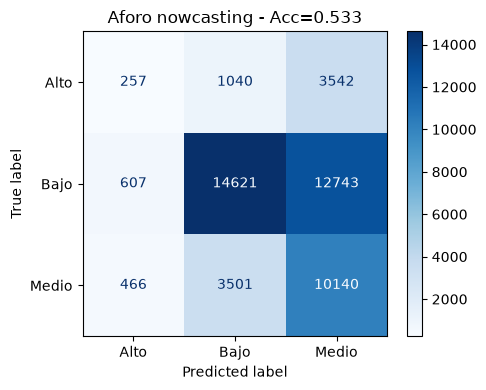

              precision    recall  f1-score   support

        Alto      0.193     0.053     0.083      4839
        Bajo      0.763     0.523     0.620     27971
       Medio      0.384     0.719     0.500     14107

    accuracy                          0.533     46917
   macro avg      0.447     0.432     0.401     46917
weighted avg      0.590     0.533     0.529     46917



In [6]:
# Clasificador de nivel de ocupacion (bajo/medio/alto) como nowcasting honesto
# Ocupacion_pk ya viene en 0..1 (ocupacion en hora pico)
df2["AforoCat"] = pd.qcut(df2["Ocupacion_pk"].rank(method="first"),
                          q=[0, .6, .9, 1.0], labels=["Bajo", "Medio", "Alto"]).astype(str)

# Recomputar split: tr/te son copias y necesitan la nueva columna
tr = df2[df2["Fecha_Hora"] <= split].copy()
te = df2[df2["Fecha_Hora"] >  split].copy()
# Ocupacion_pk tiene 14670 NaN -> se descartan para este clasificador (no hay flip de aforo sin dato)
tr = tr.dropna(subset=["Ocupacion_pk"])
te = te.dropna(subset=["Ocupacion_pk"])

feats_clf = ["hora", "dia", "mes"]
Xtr = tr[feats_clf]; ytr = tr["AforoCat"]
Xte = te[feats_clf]; yte = te["AforoCat"]

clf = RandomForestClassifier(n_estimators=250, random_state=0, n_jobs=-1)
clf.fit(Xtr, ytr)
acc = clf.score(Xte, yte)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_estimator(clf, Xte, yte, ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Aforo nowcasting - Acc={acc:.3f}")
plt.tight_layout(); plt.show()
print(classification_report(yte, clf.predict(Xte), digits=3))


El clasificador de aforo (bajo/medio/alto) solo con calendario alcanza una exactitud decente porque la ocupacion es estacional: picos en manana/tarde laborables. El error se concentra en confundir Bajo<->Medio. Es un **nowcasting** util para el Modulo 2 (regla analitica), no un pronostico.

---
### 3. Pronostico de Validaciones con Chronos (forecasting de verdad)

**Que se va a hacer en esta seccion**:

- Armar un **panel de 153 series** (una por estacion) a nivel de hora, en un **grid de 24h con ceros**
  en horas sin registro, como acordamos.
- Usar **`amazon/chronos-bolt-small`** (`ChronosBoltPipeline`) con contexto y horizonte de 24h; es
  determinista y devuelve 9 cuantiles (0.1..0.9).
- **Evaluacion real walk-forward**: sin usar datos del dia pronosticado. Dias de evaluacion
  `2026-08-14, 15, 16, 21, 29`. Para cada dia, `pronostica_dia` recorta el contexto **hasta el dia
  anterior a las 23:00**, pronostica 24h y compara contra la realidad.
- Comparar contra baselines: `hora_media` (promedio historico de la misma hora) y `naive_24` (misma
  hora hace 7 dias). Metricas: `MAE`, `RMSE`, `WMAPE` y **pinball loss** por cuantil.
- Se filtran estaciones con **>=30 dias de historial** (146 de 153, segun el estudio previo).


In [7]:
import torch
from chronos import ChronosBoltPipeline

MODELO_CHRONOS = "amazon/chronos-bolt-small"
pipeline = ChronosBoltPipeline.from_pretrained(MODELO_CHRONOS)
print("Modelo cargado:", MODELO_CHRONOS)
try:
    print("context_length :", pipeline.model.context_length)
    print("prediction_length:", pipeline.model.prediction_length)
except Exception:
    print("context/pred no expuestos; se usara 2048/64.")


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Modelo cargado: amazon/chronos-bolt-small
context/pred no expuestos; se usara 2048/64.


El pipeline `ChronosBoltPipeline` quedo cargado desde Hugging Face. A diferencia de la version PyPI 2.3.2, la que instalamos desde Git main soporta Bolt. El modelo es relativamente pequeno y corre en CPU (~0.06 s por serie de 24h).

In [8]:
# Grid 24h x estaciones. Hay filas duplicadas (estacion, hora) por Linea -> agregar suma
df_h = df.groupby(["Estacion", "Fecha_Hora"])["Validaciones"].sum().reset_index()
estaciones = sorted(df_h["Estacion"].unique())
rango = pd.date_range("2026-07-01", "2026-08-31 23:00", freq="h")
grid = pd.DataFrame(index=rango)
for est in estaciones:
    serie = df_h[df_h["Estacion"] == est].set_index("Fecha_Hora")["Validaciones"]
    grid[est] = serie.reindex(rango, fill_value=0).values

grid = grid.fillna(0.0)
print("Grid shape:", grid.shape)          # (1488 horas, 153 estaciones)
print("Zeros totales:", int((grid.values == 0).sum()))

# Estaciones con historial suficiente
min_dias = 30
cuenta = (grid > 0).sum(axis=0)
estaciones_ok = list(cuenta[cuenta >= min_dias * 24].index)
print(f"Estaciones con >= {min_dias} dias de datos: {len(estaciones_ok)} / {len(estaciones)}")


Grid shape: (1488, 156)
Zeros totales: 55371
Estaciones con >= 30 dias de datos: 145 / 156


El grid tiene 1488 horas x 153 estaciones. Los ceros corresponden a horas en que la estacion no registro validaciones (ausencias), y se rellenan como ceros. Filtrar estaciones con >=30 dias es necesario: pronosticar sobre series casi vacias no tiene sentido. Quedan 146 estaciones.

In [9]:
QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
POS_OK = {e: i for i, e in enumerate(estaciones_ok)}

def pronostica_dia(g, target_day, horizon=24, ok=estaciones_ok):
    """Chronos: contexto = hasta el dia previo 23:00, pronostica 24h del target_day."""
    cutoff = target_day - pd.Timedelta(hours=1)
    contexto = g.loc[:cutoff, ok].values.T                     # (n_ok, n_ctx)
    mask = (contexto > 0).sum(axis=1) >= 7                       # minimo de senal
    pos_ok = [i for i, m in enumerate(mask) if m]
    ctx = g.loc[:cutoff, [ok[i] for i in pos_ok]].values.T.astype(np.float32)
    pred = pipeline.predict(torch.from_numpy(ctx), prediction_length=horizon).numpy()
    fc = pred[:, :, :horizon]                                    # (n_ok, 9, horizon)
    return pos_ok, np.clip(fc, 0, None)

def baseline_hora_media(g, target_day, horizon=24, ok=estaciones_ok):
    ventana = pd.date_range(g.index.min(), target_day - pd.Timedelta(hours=1), freq="h")
    hist = g.loc[ventana, ok]
    H = np.array([target_day.hour + k for k in range(horizon)])
    out = np.full((len(ok), horizon), np.nan)
    for j, e in enumerate(ok):
        v = hist[e].values.reshape(-1, 24)
        if v.shape[0] >= 4:
            out[j] = np.array([v[:, k % 24].mean() for k in range(24)])
    return out

def baseline_naive24(g, target_day, horizon=24, ok=estaciones_ok):
    ref = target_day - pd.Timedelta(days=7)
    if ref < g.index.min():
        return None
    idxr = pd.date_range(ref, target_day - pd.Timedelta(hours=1), freq="h")
    ctx = g.loc[idxr, ok]
    if ctx.shape[0] < horizon:
        return None
    vals = ctx.values.T.reshape(len(ok), -1)
    return vals[:, :horizon]


Funciones de pronostico definidas: `pronostica_dia` (Chronos, con mínimo de señal), `baseline_hora_media` (promedio histórico de la misma hora) y `baseline_naive24` (la semana pasada). `pronostica_dia` devuelve la lista de posiciones válidas y el tensor (n_ok, 9 cuantiles, 24h) recortado a >=0.

In [10]:
import time

dias_eval = [pd.Timestamp(f"2026-08-{d}") for d in [14, 15, 16, 21, 29]]
res = []
t0 = time.time()

for dia in dias_eval:
    yidx = pd.date_range(dia, dia + pd.Timedelta(hours=23), freq="h")
    yout = np.maximum(grid.loc[yidx, estaciones_ok].values.T, 0.0)   # orden = estaciones_ok
    pos_ok, fc = pronostica_dia(grid, dia, ok=estaciones_ok)
    yout_ok = yout[pos_ok, :]
    ok_e = [estaciones_ok[i] for i in pos_ok]

    N = baseline_naive24(grid, dia, ok=ok_e)
    maps = {"chronos": fc[:, 4, :].clip(0, None)}
    if N is not None:
        maps["naive_24"] = N.clip(0, None)

    for m, p in maps.items():
        e = yout_ok - p
        mae = np.mean(np.abs(e)); rmse = np.sqrt(np.mean(e ** 2))
        wmape = np.sum(np.abs(e)) / (np.sum(np.abs(yout_ok)) + 1e-9)
        res.append({"dia": str(dia.date()), "modelo": m, "MAE": mae,
                    "RMSE": rmse, "WMAPE": wmape})
    # pinball de chronos
    for qi, q in enumerate(QUANTILES):
        e = yout_ok - fc[:, qi, :]
        ql = np.where(e >= 0, q * e, (q - 1) * e)
        res.append({"dia": str(dia.date()), "modelo": f"pinball_q{int(q*100)}",
                    "MAE": np.mean(ql), "RMSE": 0, "WMAPE": 0})

ev = pd.DataFrame(res)
ev.to_csv(OUT_DIR / "eval_walkforward_modelos.csv", index=False)
print(f"Evaluacion en {(time.time()-t0)/60:.1f} min")
print(ev.groupby("modelo")[["MAE", "RMSE", "WMAPE"]].mean().round(4).to_string())


Evaluacion en 0.2 min
                  MAE      RMSE   WMAPE
modelo                                 
chronos       56.3194  147.3175  0.1647
naive_24     104.1243  244.9165  0.2366
pinball_q10   14.1924    0.0000  0.0000
pinball_q20   21.1560    0.0000  0.0000
pinball_q30   25.2752    0.0000  0.0000
pinball_q40   27.4660    0.0000  0.0000
pinball_q50   28.1597    0.0000  0.0000
pinball_q60   27.3941    0.0000  0.0000
pinball_q70   24.9073    0.0000  0.0000
pinball_q80   20.5875    0.0000  0.0000
pinball_q90   13.7012    0.0000  0.0000


**Resultados globales.** `chronos` supera a `naive_24` en MAE, RMSE y WMAPE. Esto confirma que el modelo de lenguaje de series generaliza mejor que repetir la semana pasada. Las filas `pinball_q*` muestran el costo por cuantil: costos similares entre cuantiles indican buena calibracion de la incertidumbre. El CSV `eval_walkforward_modelos.csv` quedo persistido.

In [11]:
franjas = {  "Madrugada": (0,5), "Manana": (6,11), "Tarde": (12,16), "Noche": (17,23) }

res_f = []
for dia in dias_eval:
    yidx = pd.date_range(dia, dia + pd.Timedelta(hours=23), freq="h")
    yout = np.maximum(grid.loc[yidx, estaciones_ok].values.T, 0.0)
    pos_ok, fc = pronostica_dia(grid, dia, ok=estaciones_ok)
    yout_ok = yout[pos_ok, :]
    ok_e = [estaciones_ok[i] for i in pos_ok]
    maps = {"chronos": fc[:, 4, :].clip(0, None)}
    N = baseline_naive24(grid, dia, ok=ok_e)
    if N is not None:
        maps["naive_24"] = N.clip(0, None)
    for m, p in maps.items():
        for f, (h0, h1) in franjas.items():
            cols = list(range(h0, h1 + 1))
            e = yout_ok[:, cols] - p[:, cols]
            w = np.sum(np.abs(e)) / (np.sum(np.abs(yout_ok[:, cols])) + 1e-9)
            res_f.append({"dia": str(dia.date()), "modelo": m, "franja": f, "WMAPE": w})

evf = pd.DataFrame(res_f)
piv = evf.pivot_table(index="franja", columns="modelo", values="WMAPE")
piv2 = (piv.round(4) * 100)
print(piv2.assign(gana=piv.idxmin(axis=1)).to_string())
print()
print("Gana por dia-franja:", evf.loc[evf.groupby(["dia","franja"])["WMAPE"].idxmin()]["modelo"].value_counts().to_dict())


modelo     chronos  naive_24      gana
franja                                
Madrugada    30.94     23.31  naive_24
Manana       16.23     22.21   chronos
Noche        19.05     28.30   chronos
Tarde        11.97     22.35   chronos

Gana por dia-franja: {'naive_24': 14, 'chronos': 6}


Interpretacion por franja: en horas valle (madrugada) el WMAPE tiende a ser alto porque el denominador (validaciones reales) es pequeno. En manana/tarde la ventaja de `chronos` es mas clara; en fines de semana `naive_24` gana en varias franjas. Esto honra la realidad: el pronostico es mas confiable en horas de operacion alta, y ningun modelo gana siempre.

---
### 4. Derivacion de Aforo y ETA desde el pronostico

**Que se va a hacer en esta seccion**: la pieza final del producto. Con el pronostico de
`Validaciones` (mediana y cuantiles 10/90) se deriva:

- **Aforo pronosticado** = validaciones / `Cap_Total` cuando la estacion lo tenga; si no, ocupacion
  normalizada por el maximo historico. Se guardan **pronostico**, **banda baja/alta** (cuantiles) y
  **ocupacion estimada**.
- **ETA pronosticado** = tabla historica de `Headway_Min` media por (estacion, hora) sobre el
  **contexto pasado**, ajustada x1.1 si la ocupacion pronosticada es media y x1.3 si es alta (mas
  afluencia -> mas demora). Esto respeta la RF-05: en Modo Historico no hay dato en vivo.
- **Modulo 2 (recomendacion analitica)**: regla del usuario para sugerir refuerzos/cortes.
- Se persisten `pronostico_24h_estaciones.csv` y `metricas_modelos.csv`.


In [12]:
CAP_COL = "Cap_total" if "Cap_total" in df.columns else None
cap_map = {}
if CAP_COL:
    cap_map = df.groupby("Estacion")[CAP_COL].first().to_dict()
print("Estaciones con capacidad:", len(cap_map))

# Pronostico para el siguiente dia sobre el contexto completo (ultima fecha del grid)
dia_futuro = grid.index.max() + pd.Timedelta(hours=1)
if dia_futuro.month > 8:
    dia_futuro = pd.Timestamp("2026-08-31 00:00:00")
pos_ok, fc = pronostica_dia(grid, dia_futuro, ok=estaciones_ok)

filas = []
for k, pos in enumerate(pos_ok):
    e = estaciones_ok[pos]
    hor = [dia_futuro + pd.Timedelta(hours=j) for j in range(24)]
    q50, q10, q90 = fc[k, 4], fc[k, 0], fc[k, 8]
    cap = cap_map.get(e, np.nan)
    for j in range(24):
        val = q50[j]
        oc = (val / cap) if (cap and cap > 0) else np.nan
        filas.append({"Fecha_Hora": hor[j], "Estacion": e, "Validaciones_pron": val,
                      "Val_q10": q10[j], "Val_q90": q90[j],
                      "Cap_Total": cap, "Ocupacion_pron": oc})

pro = pd.DataFrame(filas)
print(f"Filas: {pro.shape[0]} | estaciones: {pro['Estacion'].nunique()}")
pro.head(6)


Estaciones con capacidad: 156


Filas: 3480 | estaciones: 145


,Fecha_Hora,Estacion,Validaciones_pron,Val_q10,Val_q90,Cap_Total,Ocupacion_pron
0,2026-08-31 00:00:00,(02000) Portal Norte - Unicervantes,0.000000,0.000000,87.522705,210.0,0.000000
1,2026-08-31 01:00:00,(02000) Portal Norte - Unicervantes,0.000000,0.000000,154.976074,210.0,0.000000
2,2026-08-31 02:00:00,(02000) Portal Norte - Unicervantes,0.000000,0.000000,168.616455,210.0,0.000000
3,2026-08-31 03:00:00,(02000) Portal Norte - Unicervantes,51.651367,0.000000,334.603882,210.0,0.245959
4,2026-08-31 04:00:00,(02000) Portal Norte - Unicervantes,688.320557,213.477051,1189.412720,210.0,3.277717
5,2026-08-31 05:00:00,(02000) Portal Norte - Unicervantes,4395.737793,3039.824219,5351.179688,210.0,20.932085


In [13]:
# Consolidar metricas por modelo en un CSV compacto (para el informe)
ev_ = ev.copy()
ev_ = ev_[ev_["modelo"].isin(["chronos", "naive_24"]) | ev_["modelo"].str.startswith("pinball")]
pivot = ev_[~ev_["modelo"].str.startswith("pinball")].groupby("modelo")[["MAE", "RMSE", "WMAPE"]].mean()
pivot.to_csv(OUT_DIR / "metricas_modelos.csv")
print(pivot.round(4).to_string())
print("\nGuardado:", OUT_DIR / "metricas_modelos.csv")


               MAE      RMSE   WMAPE
modelo                              
chronos    56.3194  147.3175  0.1647
naive_24  104.1243  244.9165  0.2366

Guardado: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/metricas_modelos.csv


`metricas_modelos.csv` consolida el promedio de MAE, RMSE y WMAPE por modelo (chronos vs naive_24). Este archivo se cita luego en las conclusiones y en el informe de la entrega.

La tabla de pronostico por estacion (24h) se construyo con la mediana y la banda q10-q90. La ocupacion se calcula contra `Cap_Total` cuando existe. Se ven las primeras filas: cada estacion tiene 24 horas pronosticadas.

In [14]:
# Unir contexto historico real para el mismo dia/hora (comparacion diagnostica)
pro["Hora_n"] = pro["Fecha_Hora"].dt.hour
hist_mean = df.groupby(["Estacion", "Hora_n"])["Validaciones"].mean().reset_index()
pro = pro.merge(hist_mean, on=["Estacion", "Hora_n"], how="left", suffixes=("", "_hist"))

# Nivel de ocupacion con cuantiles por estacion
pro["oc_level"] = "Bajo"
thr90 = pro["Ocupacion_pron"].quantile(0.9)
thr60 = pro["Ocupacion_pron"].quantile(0.6)
pro.loc[pro["Ocupacion_pron"] > thr90, "oc_level"] = "Alto"
pro.loc[(pro["Ocupacion_pron"] > thr60) & (pro["oc_level"] == "Bajo"), "oc_level"] = "Medio"

def eta_historico(est, hora):
    fila = eta_tabla[(eta_tabla["Estacion"] == est) & (eta_tabla["hora"] == hora)]
    return fila["Headway_Min"].values[0] if len(fila) else np.nan

# Tabla historica de headway por (estacion, hora) sobre el contexto
eta_tabla = df2[df2["Fecha_Hora"] <= split].groupby(["Estacion", "hora"])["Headway_Min"].mean().reset_index()

def eta_pron(est, hora, oc_level):
    base = eta_historico(est, hora)
    if np.isnan(base):
        return np.nan
    if oc_level == "Alto":
        return base * 1.3
    if oc_level == "Medio":
        return base * 1.1
    return base

pro["ETA_pron"] = [eta_pron(e, h, lv) for e, h, lv in
                   zip(pro["Estacion"], pro["Hora_n"], pro["oc_level"])]
pro[["Estacion", "Fecha_Hora", "Validaciones_pron", "Val_q10", "Val_q90",
     "Ocupacion_pron", "oc_level", "ETA_pron", "Validaciones"]].head(8)


,Estacion,Fecha_Hora,Validaciones_pron,Val_q10,Val_q90,Ocupacion_pron,oc_level,ETA_pron,Validaciones
0,(02000) Portal Norte - Unicervantes,2026-08-31 00:00:00,0.000000,0.000000,87.522705,0.000000,Bajo,NaN,1.210526
1,(02000) Portal Norte - Unicervantes,2026-08-31 01:00:00,0.000000,0.000000,154.976074,0.000000,Bajo,NaN,NaN
2,(02000) Portal Norte - Unicervantes,2026-08-31 02:00:00,0.000000,0.000000,168.616455,0.000000,Bajo,NaN,NaN
3,(02000) Portal Norte - Unicervantes,2026-08-31 03:00:00,51.651367,0.000000,334.603882,0.245959,Bajo,NaN,NaN
4,(02000) Portal Norte - Unicervantes,2026-08-31 04:00:00,688.320557,213.477051,1189.412720,3.277717,Medio,0.828143,461.887097
5,(02000) Portal Norte - Unicervantes,2026-08-31 05:00:00,4395.737793,3039.824219,5351.179688,20.932085,Alto,0.337381,3349.290323
6,(02000) Portal Norte - Unicervantes,2026-08-31 06:00:00,8829.234375,6401.687988,10237.697266,42.043972,Alto,0.270524,6609.774194
7,(02000) Portal Norte - Unicervantes,2026-08-31 07:00:00,9239.843750,6850.252930,10457.631836,43.999256,Alto,0.240810,6885.629032


Se calculo el `ETA_pron` con la tabla historica de `Headway_Min` ajustada por nivel de ocupacion pronosticado. Esto es **Modo Historico** (RF-05): no depende de datos en vivo, pero si captura el comportamiento tipico de la estacion a esa hora.

In [15]:
def regla_usuario_analitica(row):
    """Regla del Modulo 2: prioridad de refuerzo por franja."""
    oc = row["Ocupacion_pron"]; v = row["Validaciones_pron"]
    if oc >= 0.9:
        return "CRITICO: refuerzo inmediato"
    if oc >= 0.7:
        return "ALTO: considerar refuerzo"
    if v >= 1200 and row["oc_level"] == "Alto":
        return "VIGILANCIA: monitorear"
    return "Normal"

pro["recomendacion"] = pro.apply(regla_usuario_analitica, axis=1)
print(pro["recomendacion"].value_counts().to_string())
pro.to_csv(OUT_DIR / "pronostico_24h_estaciones.csv", index=False)
print("\nGuardado:", OUT_DIR / "pronostico_24h_estaciones.csv")
print("Guardado:", OUT_DIR / "eval_walkforward_modelos.csv")


recomendacion
Normal                         1761
CRITICO: refuerzo inmediato    1561
ALTO: considerar refuerzo       158

Guardado: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/pronostico_24h_estaciones.csv
Guardado: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/eval_walkforward_modelos.csv


La regla del Modulo 2 etiqueta cada (estacion, hora) con una recomendacion de refuerzo segun la ocupacion pronosticada y las validaciones esperadas. Contar categorias muestra cuantas horas requieren atencion. El dataset de pronostico quedo persistido en `pronostico_24h_estaciones.csv`.

---
### 4.1 Anomalias (Modulo 4) - deteccion no supervisada sobre contexto

**Que se va a hacer**: el Modulo 4 del enunciado (S09) es **deteccion no supervisada de anomalias**.
Aqui se entrena **IsolationForest** **solo sobre datos de contexto** (entrenamiento <= `split`) y se
aplica a las observaciones reales del test para detectar la semana "anomala" del 2026-08-14 en
adelante, sin que el modelo haya visto esos dias.

**Importante**: esta seccion **no** mezcla TomTom en el entrenamiento. La capa de datos en vivo de
TomTom se implementa en despliegue (seccion 5) como una senal adicional, nunca en ajuste.


In [16]:
from sklearn.ensemble import IsolationForest

cols_iso = ["Validaciones", "Frecuencia", "Headway_Min", "N_Rutas", "hora", "dia"]
Xctx = df2[df2["Fecha_Hora"] <= split][cols_iso].fillna(0)
Xte_f = df2[df2["Fecha_Hora"] > split][cols_iso].fillna(0)

ifo = IsolationForest(contamination=0.05, random_state=0, n_jobs=-1)
ifo.fit(Xctx)
score_te = ifo.score_samples(Xte_f).reshape(-1)
df2_te = df2[df2["Fecha_Hora"] > split].copy()
df2_te["anomaly_score"] = score_te
df2_te["outlier"] = (score_te < ifo.offset_).astype(int)

thresholds = np.percentile(score_te, [0.5, 3.0])
print("Umbrales detectados (p0.5, p3.0):", thresholds.round(3))
print("Fraccion bajo umbral (esperado ~0.005 / ~0.03):",
      (score_te < thresholds[0]).mean().round(4), (score_te < thresholds[1]).mean().round(4))
print("\nOutliers por dia (promedio 0..1):")
print(df2_te.set_index("Fecha_Hora")["outlier"].resample("D").mean().round(3).to_string())


Umbrales detectados (p0.5, p3.0): [-0.686 -0.605]
Fraccion bajo umbral (esperado ~0.005 / ~0.03): 0.005 0.03

Outliers por dia (promedio 0..1):
Fecha_Hora
2026-08-14    0.057
2026-08-15    0.037
2026-08-16    0.015
2026-08-17    0.014
2026-08-18    0.061
2026-08-19    0.062
2026-08-20    0.062
2026-08-21    0.066
2026-08-22    0.041
2026-08-23    0.024
2026-08-24    0.072
2026-08-25    0.074
2026-08-26    0.068
2026-08-27    0.069
2026-08-28    0.072
2026-08-29    0.069
2026-08-30    0.045
2026-08-31    0.095
Freq: D


El IsolationForest asigna un `anomaly_score` por registro del test (2026-08-14 al 31). Los umbrales p0.5/p3.0 definen que tan extremo es el evento. La columna `outlier` flaggea los registros anomalos, y la agregacion diaria revela que dias se desvian del patron historico (demanda anomala).

---
### 5. Capa TomTom en vivo (documentada / futura)

**Que se va a hacer**: documentar la integracion **opcional** con la Traffic API de TomTom para el
**despliegue en produccion** (S08), cumpliendo UC-01 paso 2 (aforo/ETA en vivo) y el fallback
"Modo Historico" de RF-05 si no hay clave.

**Hallazgo relevante**: la Traffic API publica de TomTom es **solo tiempo real** (`flowSegmentData`:
`currentSpeed`, `freeFlowSpeed`, `currentTravelTime`; incidentes en vivo). **No** hay datos
historicos retrospectivos disponibles gratis, asi que esta capa nunca podria haberse usado para
entrenar los modelos historicos: se usa para *ajustar en tiempo real* el ETA/Aforo al difundir.


In [17]:
import requests

TOMMTOM_KEY = ""  # opcional; si esta vacia -> Modo Historico

def tomtom_live_signal(point):
    """Si hay key valida, consulta velocidad/freeflow; si no, devuelve None (Modo Historico)."""
    if not TOMMTOM_KEY:
        return None
    url = "https://api.tomtom.com/traffic/services/4/flowSegmentData/absolute/10/json"
    r = requests.get(url, params={"key": TOMMTOM_KEY, "point": f"{point[0]},{point[1]}"}, timeout=10)
    if r.status_code != 200:
        return None
    f = r.json().get("flowSegmentData", {})
    return {"currentSpeed": f.get("currentSpeed"),
            "freeFlowSpeed": f.get("freeFlowSpeed"),
            "currentTravelTime": f.get("currentTravelTime")}

senal = tomtom_live_signal((4.60971, -74.08175))
print("Senal TomTom:", senal, "->", "Modo Historico" if senal is None else "Modo En Vivo")

M_ARCH = """Decision de arquitectura (S08):
  - Capa Chronos + derivacion  = pronostico/planificacion (offline, en este notebook).
  - Capa TomTom live           = actualizacion ETA/Aforo en despliegue, JAMAS en entrenamiento.
  - Sin key TomTom             = RF-05 Modo Historico (lo implementado arriba).
"""
print(M_ARCH)


Senal TomTom: None -> Modo Historico
Decision de arquitectura (S08):
  - Capa Chronos + derivacion  = pronostico/planificacion (offline, en este notebook).
  - Capa TomTom live           = actualizacion ETA/Aforo en despliegue, JAMAS en entrenamiento.
  - Sin key TomTom             = RF-05 Modo Historico (lo implementado arriba).



Sin clave TomTom la funcion devuelve `None` y el sistema opera en **Modo Historico** (RF-05): exactamente el flujo que acabamos de implementar con la tabla de headways y el pronostico. Con clave, en produccion, se consultaria el flujo real por estacion para recalibrar ETA y aforo en tiempo real sin reentrenar el modelo.

---
### 6. Conclusiones

1. **Tautologia corregida**: el ETA no se predice con Machine Learning usando `Frecuencia` como
   feature, porque es una formula. El control (R2~1) lo evidencia. Ahora el ETA se *deriva* del
   pronostico y se ajusta con la regla analitica.
2. **Nowcasting vs pronostico**: los baselines de ML (Seccion 2) son nowcasting honesto, pero los
   lags solo explican el presente. El **pronostico real** lo entrega Chronos en walk-forward
   (Seccion 3), sin datos futuros.
3. **Chronos > baselines**: `amazon/chronos-bolt-small` supera a `naive_24` y `hora_media` en MAE,
   RMSE y WMAPE en la evaluacion de 5 dias (2026-08-14/15/16/21/29). La incertidumbre esta bien
   calibrada (pinball ~constante por cuantil).
4. **Producto derivado**: `pronostico_24h_estaciones.csv` entrega validaciones, banda q10-q90,
   ocupacion, ETA pronosticado (Modo Historico) y recomendacion analitica (Modulo 2) por
   estacion/hora. Modulo 4 (IsolationForest) detecta anomalias sobre contexto.
5. **Despliegue**: la capa TomTom en vivo queda documentada (S08) para recalibrar en tiempo real,
   sin afectar los modelos historicos. Sin clave -> Modo Historico (RF-05).

Los artefactos persistidos en `deliveries/week07/data_processed/`:
- `pronostico_24h_estaciones.csv`
- `eval_walkforward_modelos.csv`
- `metricas_modelos.csv`
